In [1]:
import os
import geopandas as gpd
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
os.environ["PATH"] = f"/opt/homebrew/bin:{os.environ['PATH']}"

load_dotenv()

llm = ChatOpenAI(
    model=os.getenv("CHAT_MODEL"),
    base_url=os.getenv("BASE_URL") + "/v1",
    temperature=float(os.getenv("TEMPERATURE", "0")),
    api_key=os.getenv("OPENAI_API_KEY") or "dummy",
)

import geopandas as gpd

# baseline_blocks = gpd.read_file('./data/gatchina/blocks_clean_gatchina.geojson')
baseline_blocks = gpd.read_file('./data/gatchina/blocks_agg_with_indicators.geojson')
baseline_blocks.head()



,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,area_accessibility,fsi,gsi,mxi,l,osr,share_living,share_non_living,morphotype,geometry
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,10.063987,0.012109,0.008829,0.091908,1.371459,81.852753,0.126048,1.245411,individual residential,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,10.210398,0.212156,0.036428,0.712492,5.824002,4.541808,4.149554,1.674447,mid-rise,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,8.669212,0.303551,0.056576,0.786029,5.365401,3.107955,4.217362,1.148039,mid-rise,"POLYGON ((30.12546 59.58002, 30.12541 59.57998..."
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,7.467434,0.173716,0.075903,0.198114,2.288643,5.319595,0.453413,1.835230,low-rise model,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,8.285434,0.156696,0.071648,0.095598,2.187029,5.924533,0.209075,1.977953,low-rise model,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."


In [2]:
import sys
from pathlib import Path

repo_root = Path("/Users/mvin/Code/Urbanomy")
src_path = str(repo_root / "src")

if src_path not in sys.path:
    sys.path.insert(0, src_path)

import urbanomy
print(urbanomy.__file__)


/home/mvin/Urbanomy/src/urbanomy/__init__.py


In [3]:
from catboost import CatBoostRegressor
model = CatBoostRegressor()
model.load_model('./data/catboost_land_value_no_services.cbm')  # модель на лог-цене
print(len(model.feature_names_))

feature_cols = [
'residential','business','recreation','industrial','transport','special',
'agriculture','land_use','share','footprint_area','build_floor_area',
'living_area','non_living_area','population','site_area','fsi','gsi',
'mxi','l','morphotype','area_accessibility'
]
cat_features = ['land_use', 'morphotype']
numeric_feats = [c for c in feature_cols if c not in cat_features]

101


In [5]:
from urbanomy.methods.agent_interface import (
    DistrictOptimizationConfig,
    create_urbanomy_orchestrator,
)


opt_config = DistrictOptimizationConfig(
    model=model,
    orig_features=numeric_feats + cat_features,
    categorical_features=cat_features,
)

orchestrator = create_urbanomy_orchestrator(
    llm=llm,
    baseline_blocks=baseline_blocks,
    district_optimization_config=opt_config,
)

orchestrator.set_thread("demo2")


'demo2'

In [11]:
orchestrator.ask("""
document_name=Стратегия Гатчина
document_type=development_strategy
document_path=/Users/mvin/Code/Urbanomy/examples/data/gatchina/ССЭР Гатчинский.docx
""")

Документ 'Стратегия Гатчина' зарегистрирован как active RAG context.
Индексировано фрагментов: 800.
Retrieval backend: ollama_inmemory_vectorstore.

Краткая сводка: Приложение к решению совета депутатов Гатчинского муниципального района от 23 ноября 2018 года № 336 «СТРАТЕГИЯ СОЦИАЛЬНО-ЭКОНОМИЧЕСКОГО РАЗВИТИЯ ГАТЧИНСКОГО МУНИЦИПАЛЬНОГО РАЙОНА НА ПЕРИОД ДО 2030 ГОДА» ОГЛАВЛЕНИЕ введение 4 1. Анализ раз…

Извлечённые приоритеты:
- приоритет жилой функции и качества среды
- приоритет деловой активности и рабочих мест
- приоритет рекреации и общественных пространств
- требование инвестиционной устойчивости

In [19]:
orchestrator("Какие основные цели развития гатчины согласно документу Стратегия Гатчина?")

Основные цели развития Гатчины — создание полюса роста инновационной экономики федерального значения, в том числе : создание на базе реакторного комплекса ПИК Международного центра нейтронных исследований, развитие Северо‑Западного нанотехнологического центра, а также превращение города в центр туризма международного и всероссийского значения【chunk-379】.

In [20]:
orchestrator("что такое город?")


Город — это крупный населённый пункт с развитой инфраструктурой, где сосредоточены жильё, работа, услуги, культура и управление, обычно имеющий административный статус и собственные органы власти.

In [6]:
orchestrator("что ты умеешь?")

Я могу:

- Отвечать на общие вопросы и объяснять возможности Orchestrator.  
- Получать параметры квартала (по id или target_id) из базовых данных.  
- Визуализировать карты: полную стоимость земли, стоимость за 100 м² и выделение квартала по target_id.  
- Консультировать по постановке задачи оптимизации квартала, ограничениям и переменным.  
- Запускать оптимизацию квартала, выводить количество найденных решений и их Pareto‑фронт.  
- Визуализировать конкретное Pareto‑решение, показывать его параметры и рассчитывать инвестиционные метрики.  
- Строить график Pareto‑фронта.  
- Регистрировать генплан или стратегию как RAG‑policy‑документ, извлекать из него релевантные фрагменты и выбирать лучшее решение по активному документу.  

Все операции выполняются через встроенные инструменты, перечисленные в каталоге. Если нужен более детальный пример — сообщите, что именно интересует.

In [5]:
orchestrator("какие инструменты у тебя есть?")

Я могу объяснять возможности Urbanomy и отвечать на вопросы по текущему контексту.

Каталог инструментов:
- predict_land_value: What the tool does.
- plot_total_land_value_map: What the tool does.
- plot_land_value_per_100m2_map: What the tool does.
- plot_target_block_map: What the tool does.
- block_parameters: Возвращает baseline-параметры квартала по id или target_id без построения карты.
- register_decision_document: What the tool does.
- get_active_decision_document: What the tool does.
- retrieve_decision_document_context: What the tool does.
- select_pareto_solution_by_document: What the tool does.
- get_orchestrator_context: What the tool does.
- get_orchestrator_tool_catalog: What the tool does.
- get_block_parameter_definition: What the tool does.
- run_district_optimization: What the tool does.
- plot_pareto_solution_impact: What the tool does.
- calculate_pareto_solution_investment_metrics: What the tool does.
- get_pareto_solution_parameters: What the tool does.
- get_dis

In [21]:
orchestrator("что такое fsi в параметрах кварталов")

FSI: Floor Space Index: отношение суммарной поэтажной площади к площади участка.
Формула: fsi = build_floor_area / site_area
Смысл: Показывает интенсивность использования территории.

In [22]:
orchestrator("сколько будет 2+2?")

4.

In [6]:
orchestrator("Вычисли стоимость земли за сотку для кварталов")

Перед выполнением нужен экспертный confirm-gate. Проверь, что я правильно понял запрос, шаги и инструменты.
Планируемые инструменты:
- predict_land_value
Research brief:
маршрут: visualization
сложность: multi_step
сводка: Нужно обработать multi_step запрос по маршруту visualization: прогноз стоимости земли.
ожидаемые результаты:
- прогноз стоимости земли
выделенные сущности:
- route: visualization
- requested_output: прогноз стоимости земли
План выполнения:
маршрут: visualization
сложность: multi_step
цель: Нужно обработать multi_step запрос по маршруту visualization: прогноз стоимости земли.
шаги:
- 1. Определить тип карты — Понять, нужна ли карта квартала, полной стоимости или стоимости за сотку.
- 2. Построить визуализацию — Вызвать согласованный plotting tool и сохранить артефакт в session memory.
Если всё верно, ответьте: да
Если нужно скорректировать план, ответьте: нет или напишите уточнение.

In [7]:
orchestrator("да")

Подтверждение принято. Выполняю согласованный план.

Стоимость земли за сотку (land_value_per_100m2) рассчитана для всех кварталов. Данные обновлены в наборе `baseline_blocks`.

In [8]:
orchestrator("Покажи стоимость земли")

Перед выполнением нужен экспертный confirm-gate. Проверь, что я правильно понял запрос, шаги и инструменты.
Планируемые инструменты:
- plot_total_land_value_map
Research brief:
маршрут: visualization
сложность: multi_step
сводка: Нужно обработать multi_step запрос по маршруту visualization: visualization.
ожидаемые результаты:
- visualization
выделенные сущности:
- route: visualization
- requested_output: visualization
План выполнения:
маршрут: visualization
сложность: multi_step
цель: Нужно обработать multi_step запрос по маршруту visualization: visualization.
шаги:
- 1. Определить тип карты — Понять, нужна ли карта квартала, полной стоимости или стоимости за сотку.
- 2. Построить визуализацию — Вызвать согласованный plotting tool и сохранить артефакт в session memory.
Если всё верно, ответьте: да
Если нужно скорректировать план, ответьте: нет или напишите уточнение.

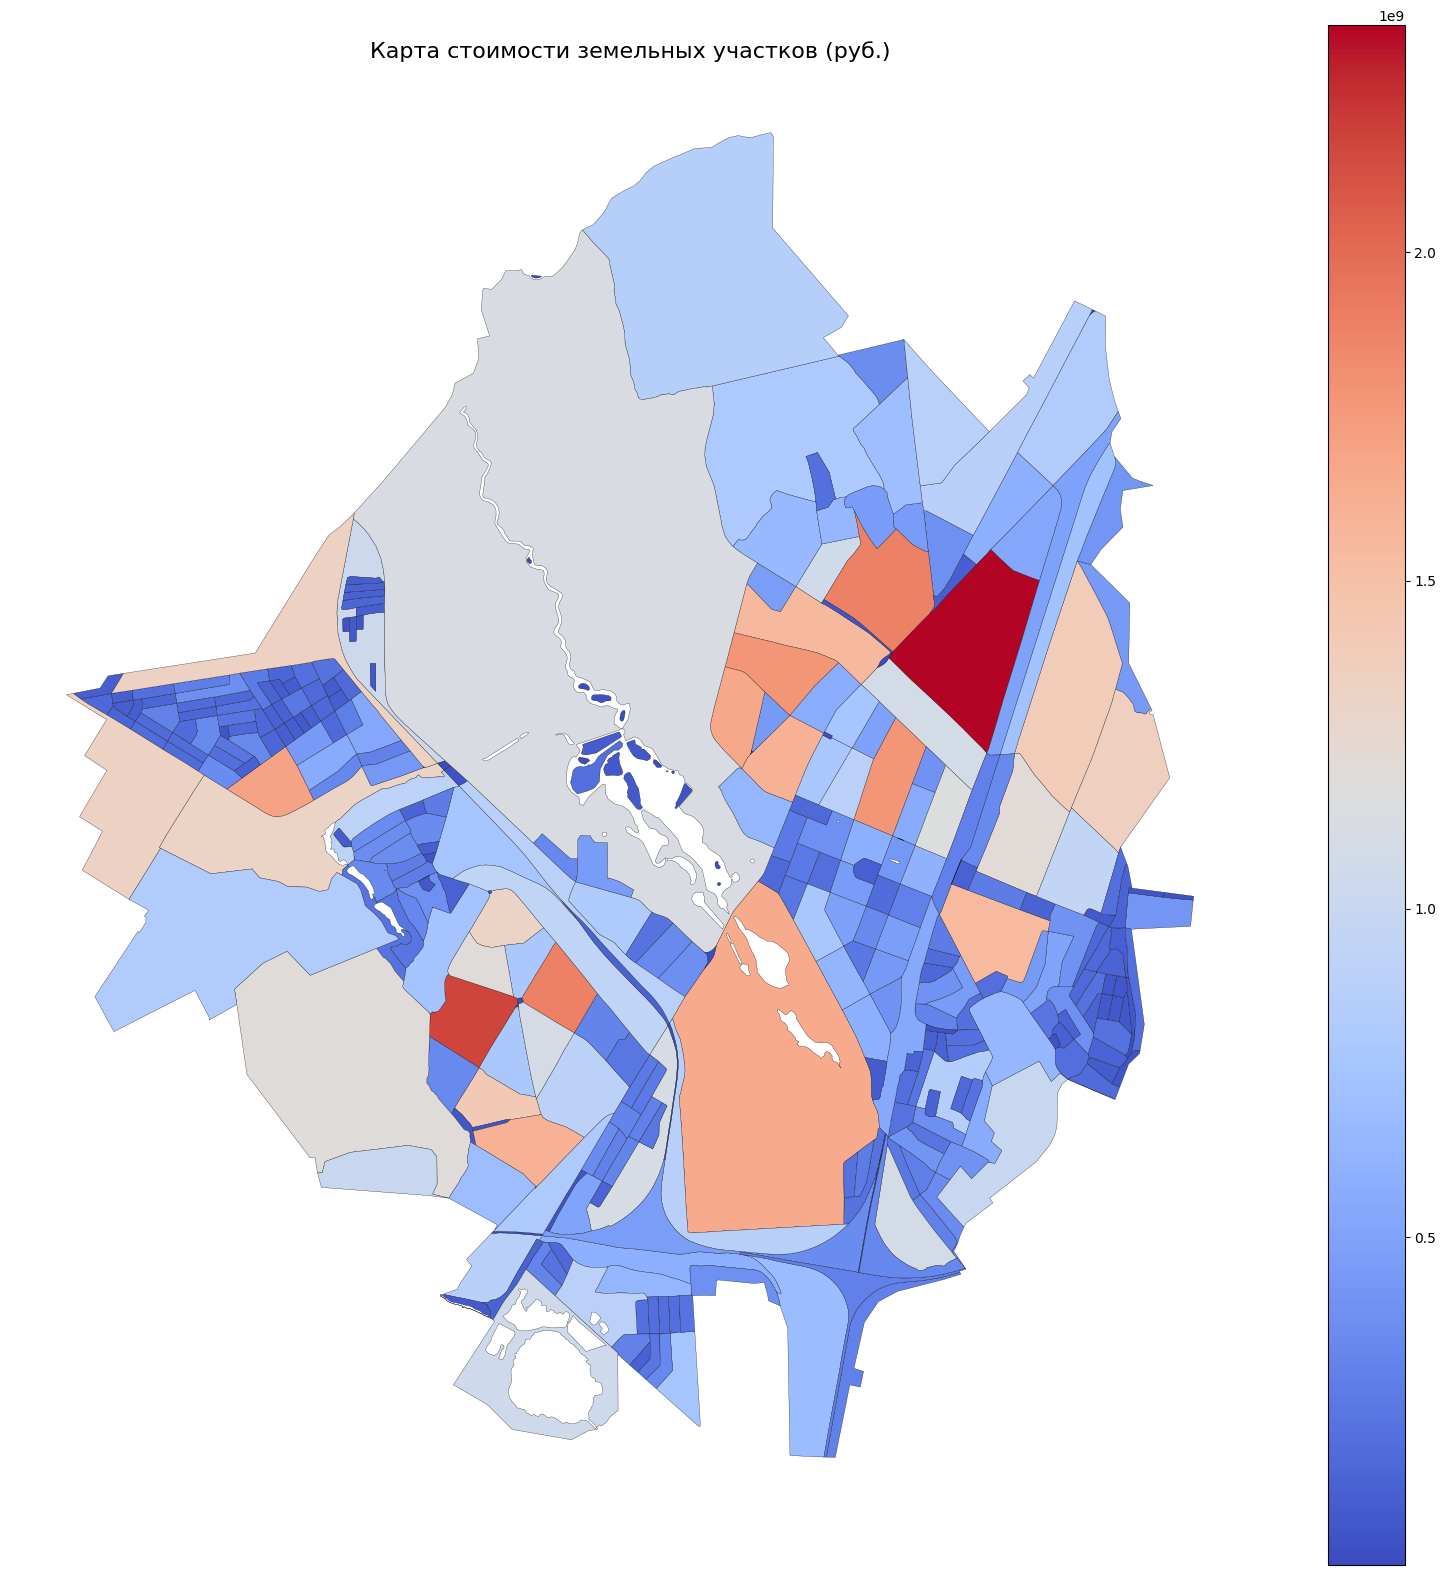

Подтверждение принято. Выполняю согласованный план.

Карта стоимости земли построена. На ней отображены значения общего земельного капитала (руб.) для всех 351 блока.

In [9]:
orchestrator("да")

In [25]:
orchestrator("Покажи квартал с target_id=86")

Перед выполнением нужен экспертный confirm-gate. Проверь, что я правильно понял запрос, шаги и инструменты.
Планируемые инструменты:
- plot_target_block_map
Research brief:
маршрут: visualization
сложность: multi_step
сводка: Нужно обработать multi_step запрос по маршруту visualization для target_id=86: карта квартала.
target_id: 86
ожидаемые результаты:
- карта квартала
выделенные сущности:
- route: visualization
- target_id: 86
- requested_output: карта квартала
План выполнения:
маршрут: visualization
сложность: multi_step
цель: Нужно обработать multi_step запрос по маршруту visualization для target_id=86: карта квартала.
шаги:
- 1. Определить тип карты — Понять, нужна ли карта квартала, полной стоимости или стоимости за сотку.
- 2. Построить визуализацию — Вызвать согласованный plotting tool и сохранить артефакт в session memory.
Если всё верно, ответьте: да
Если нужно скорректировать план, ответьте: нет или напишите уточнение.

In [29]:
orchestrator("Какое население у квартала 86?")

Население квартала id=86: 1389

In [32]:
orchestrator("Какие параметры у квартала 86?")

Параметры квартала id=86:
 • id: 86
 • site_area: 262250.979778
 • land_use: LandUse.BUSINESS
 • land_value: 651922266.225923
 • land_value_per_100m2: 248587.161344
 • build_floor_area: 107107.690178
 • footprint_area: 47096.975151
 • living_area: 44241.785252
 • non_living_area: 62865.904925
 • population: 1389
 • fsi: 0.105045
 • gsi: 0.04619
 • mxi: 0.413059
 • residential: 0.268468
 • business: 0.648297
 • recreation: 0.065871
 • industrial: 0
 • transport: 0.01739
 • special: 0
 • agriculture: 0
 • area_accessibility: 9.513417
 • l: 2.274195
 • morphotype: low-rise model
 • share: 0.648297

In [33]:
orchestrator("Покажи ограничения в задаче оптимизации")

Перед выполнением нужен экспертный confirm-gate. Проверь, что я правильно понял запрос, шаги и инструменты.
Планируемые инструменты:
- run_district_optimization
- get_district_optimization_constraints
- plot_pareto_solution_impact
Research brief:
маршрут: district_optimization
сложность: multi_step
сводка: Нужно обработать multi_step запрос по маршруту district_optimization: запуск оптимизации, объяснение ограничений, визуализация решения.
ожидаемые результаты:
- запуск оптимизации
- объяснение ограничений
- визуализация решения
выделенные сущности:
- route: district_optimization
- requested_output: запуск оптимизации
- requested_output: объяснение ограничений
- requested_output: визуализация решения
План выполнения:
маршрут: district_optimization
сложность: multi_step
цель: Нужно обработать multi_step запрос по маршруту district_optimization: запуск оптимизации, объяснение ограничений, визуализация решения.
шаги:
- 1. Уточнить optimization context — Определить target_id, активную сесс

In [34]:
orchestrator("Да")

Подтверждение принято. Выполняю согласованный план.

Ограничения оптимизации:
 • target_id: не задан
 • source: config_defaults_symbolic
 • site_area: не задана, поэтому формулы могут быть символическими
Диапазоны переменных:
 • footprint_area [float]: min=0.0, max=0.1 * site_area
 • l [float]: min=1.0, max=10.0
 • mxi [float]: min=0.0, max=1.0
 • residential [float]: min=0.0, max=1.0
 • business [float]: min=0.0, max=1.0
 • recreation [float]: min=0.0, max=1.0
 • industrial [float]: min=0.0, max=1.0
 • transport [float]: min=0.0, max=1.0
 • special [float]: min=0.0, max=1.0
 • agriculture [float]: min=0.0, max=1.0
Примечание: без target_id показаны шаблонные ограничения до подстановки site_area.

In [37]:
orchestrator("Покажи параметры оптимизатора")

Перед выполнением нужен экспертный confirm-gate. Проверь, что я правильно понял запрос, шаги и инструменты.
Планируемые инструменты:
- run_district_optimization
- get_pareto_solution_parameters
- plot_pareto_solution_impact
Research brief:
маршрут: district_optimization
сложность: multi_step
сводка: Нужно обработать multi_step запрос по маршруту district_optimization: запуск оптимизации, параметры решения, визуализация решения.
ожидаемые результаты:
- запуск оптимизации
- параметры решения
- визуализация решения
выделенные сущности:
- route: district_optimization
- requested_output: запуск оптимизации
- requested_output: параметры решения
- requested_output: визуализация решения
План выполнения:
маршрут: district_optimization
сложность: multi_step
цель: Нужно обработать multi_step запрос по маршруту district_optimization: запуск оптимизации, параметры решения, визуализация решения.
шаги:
- 1. Уточнить optimization context — Определить target_id, активную сессию и нужный тип результата.

In [38]:
orchestrator("Да")

Подтверждение принято. Выполняю согласованный план.

Постановка задачи оптимизации готова. target_id пока не задан. Переменных: 0. Параметры алгоритма: pop_size=10, n_gen=15, seed=42.

In [39]:
orchestrator("Покажи полные параметры оптимизации")

Перед выполнением нужен экспертный confirm-gate. Проверь, что я правильно понял запрос, шаги и инструменты.
Планируемые инструменты:
- run_district_optimization
- get_pareto_solution_parameters
- plot_pareto_solution_impact
Research brief:
маршрут: district_optimization
сложность: multi_step
сводка: Нужно обработать multi_step запрос по маршруту district_optimization: запуск оптимизации, параметры решения, визуализация решения.
ожидаемые результаты:
- запуск оптимизации
- параметры решения
- визуализация решения
выделенные сущности:
- route: district_optimization
- requested_output: запуск оптимизации
- requested_output: параметры решения
- requested_output: визуализация решения
План выполнения:
маршрут: district_optimization
сложность: multi_step
цель: Нужно обработать multi_step запрос по маршруту district_optimization: запуск оптимизации, параметры решения, визуализация решения.
шаги:
- 1. Уточнить optimization context — Определить target_id, активную сессию и нужный тип результата.

In [40]:
orchestrator("Да")

Подтверждение принято. Выполняю согласованный план.

Постановка задачи оптимизации:
 • target_id: не задан
 • source: config_defaults
 • site_area: будет определена после выбора квартала
Целевые функции:
 • total_land_value (maximize): Суммарная стоимость земли после сценарного изменения квартала.
 • investor_npv (maximize): NPV проекта для изменяемого квартала по инвестиционной модели.
Переменные решения и диапазоны:
 • Для точных диапазонов укажи target_id или сначала запусти оптимизацию квартала.
Правила repair / нормализации:
 • Доли land_use нормализуются так, чтобы их сумма была равна 1.0.
 • Если все доли land_use нулевые, сценарий принудительно становится residential=1.0.
 • footprint_area ограничивается сверху значением 0.8 * site_area после выбора конкретного квартала.
 • l ограничивается снизу значением 1.0.
 • mxi ограничивается диапазоном [0.0, 1.0].
 • Доминирующая доля land_use определяет итоговый land_use квартала.
 • Производные показатели build_floor_area, living_area

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       10 |      1 |             - |             -
     2 |       20 |      1 |  6.622146E+07 |         ideal
     3 |       30 |      2 |  1.0000000000 |         ideal
     4 |       40 |      1 |  4.449188E+08 |         ideal
     5 |       50 |      1 |  4.882480E+07 |         ideal
     6 |       60 |      4 |  0.9978987572 |         ideal
     7 |       70 |      1 |  1.376257E+08 |         ideal
     8 |       80 |      3 |  0.4808934655 |         ideal
     9 |       90 |      2 |  1.1076620282 |         ideal
    10 |      100 |      1 |  2.458242E+08 |         ideal
    11 |      110 |      2 |  1.0000000000 |         ideal
    12 |      120 |      3 |  0.0479566371 |         ideal
    13 |      130 |      3 |  0.1803217805 |         ideal
    14 |      140 |      4 |  0.0137609835 |         ideal
    15 |      150 |      4 |  0.1785858123 |         ideal


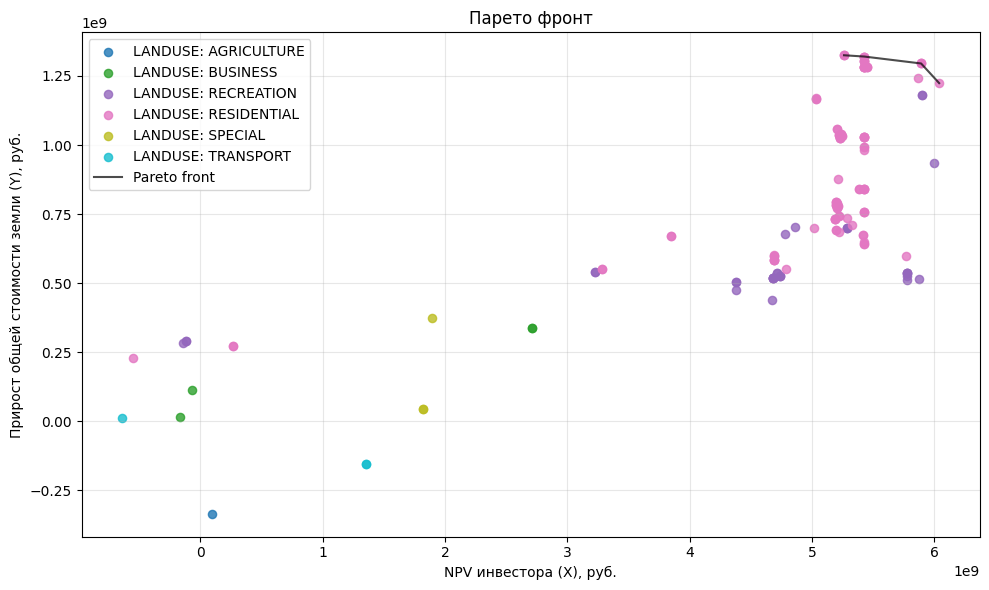

Оптимизация завершена. Найдено 4 оптимальных решения.

Построен график Парето-фронта.
 • Всего точек: 150
 • Точек на фронте: 4
 • Категории LANDUSE: AGRICULTURE, BUSINESS, RECREATION, RESIDENTIAL, SPECIAL, TRANSPORT

In [ ]:
orchestrator("Оптимизируй квартал с target_id=86")

In [41]:
orchestrator("что такое RESIDENTIAL?")

**Residential** — это термин, обозначающий жилой (проживательный) тип недвижимости или зоны. В контексте недвижимости он относится к объектам, предназначенным для постоянного проживания людей (квартиры, дома, таунхаусы и т.п.), а в градостроительстве — к жилым районам, где преимущественно расположены такие объекты.

In [ ]:
orchestrator("какие парамерты застройки в решение 2")

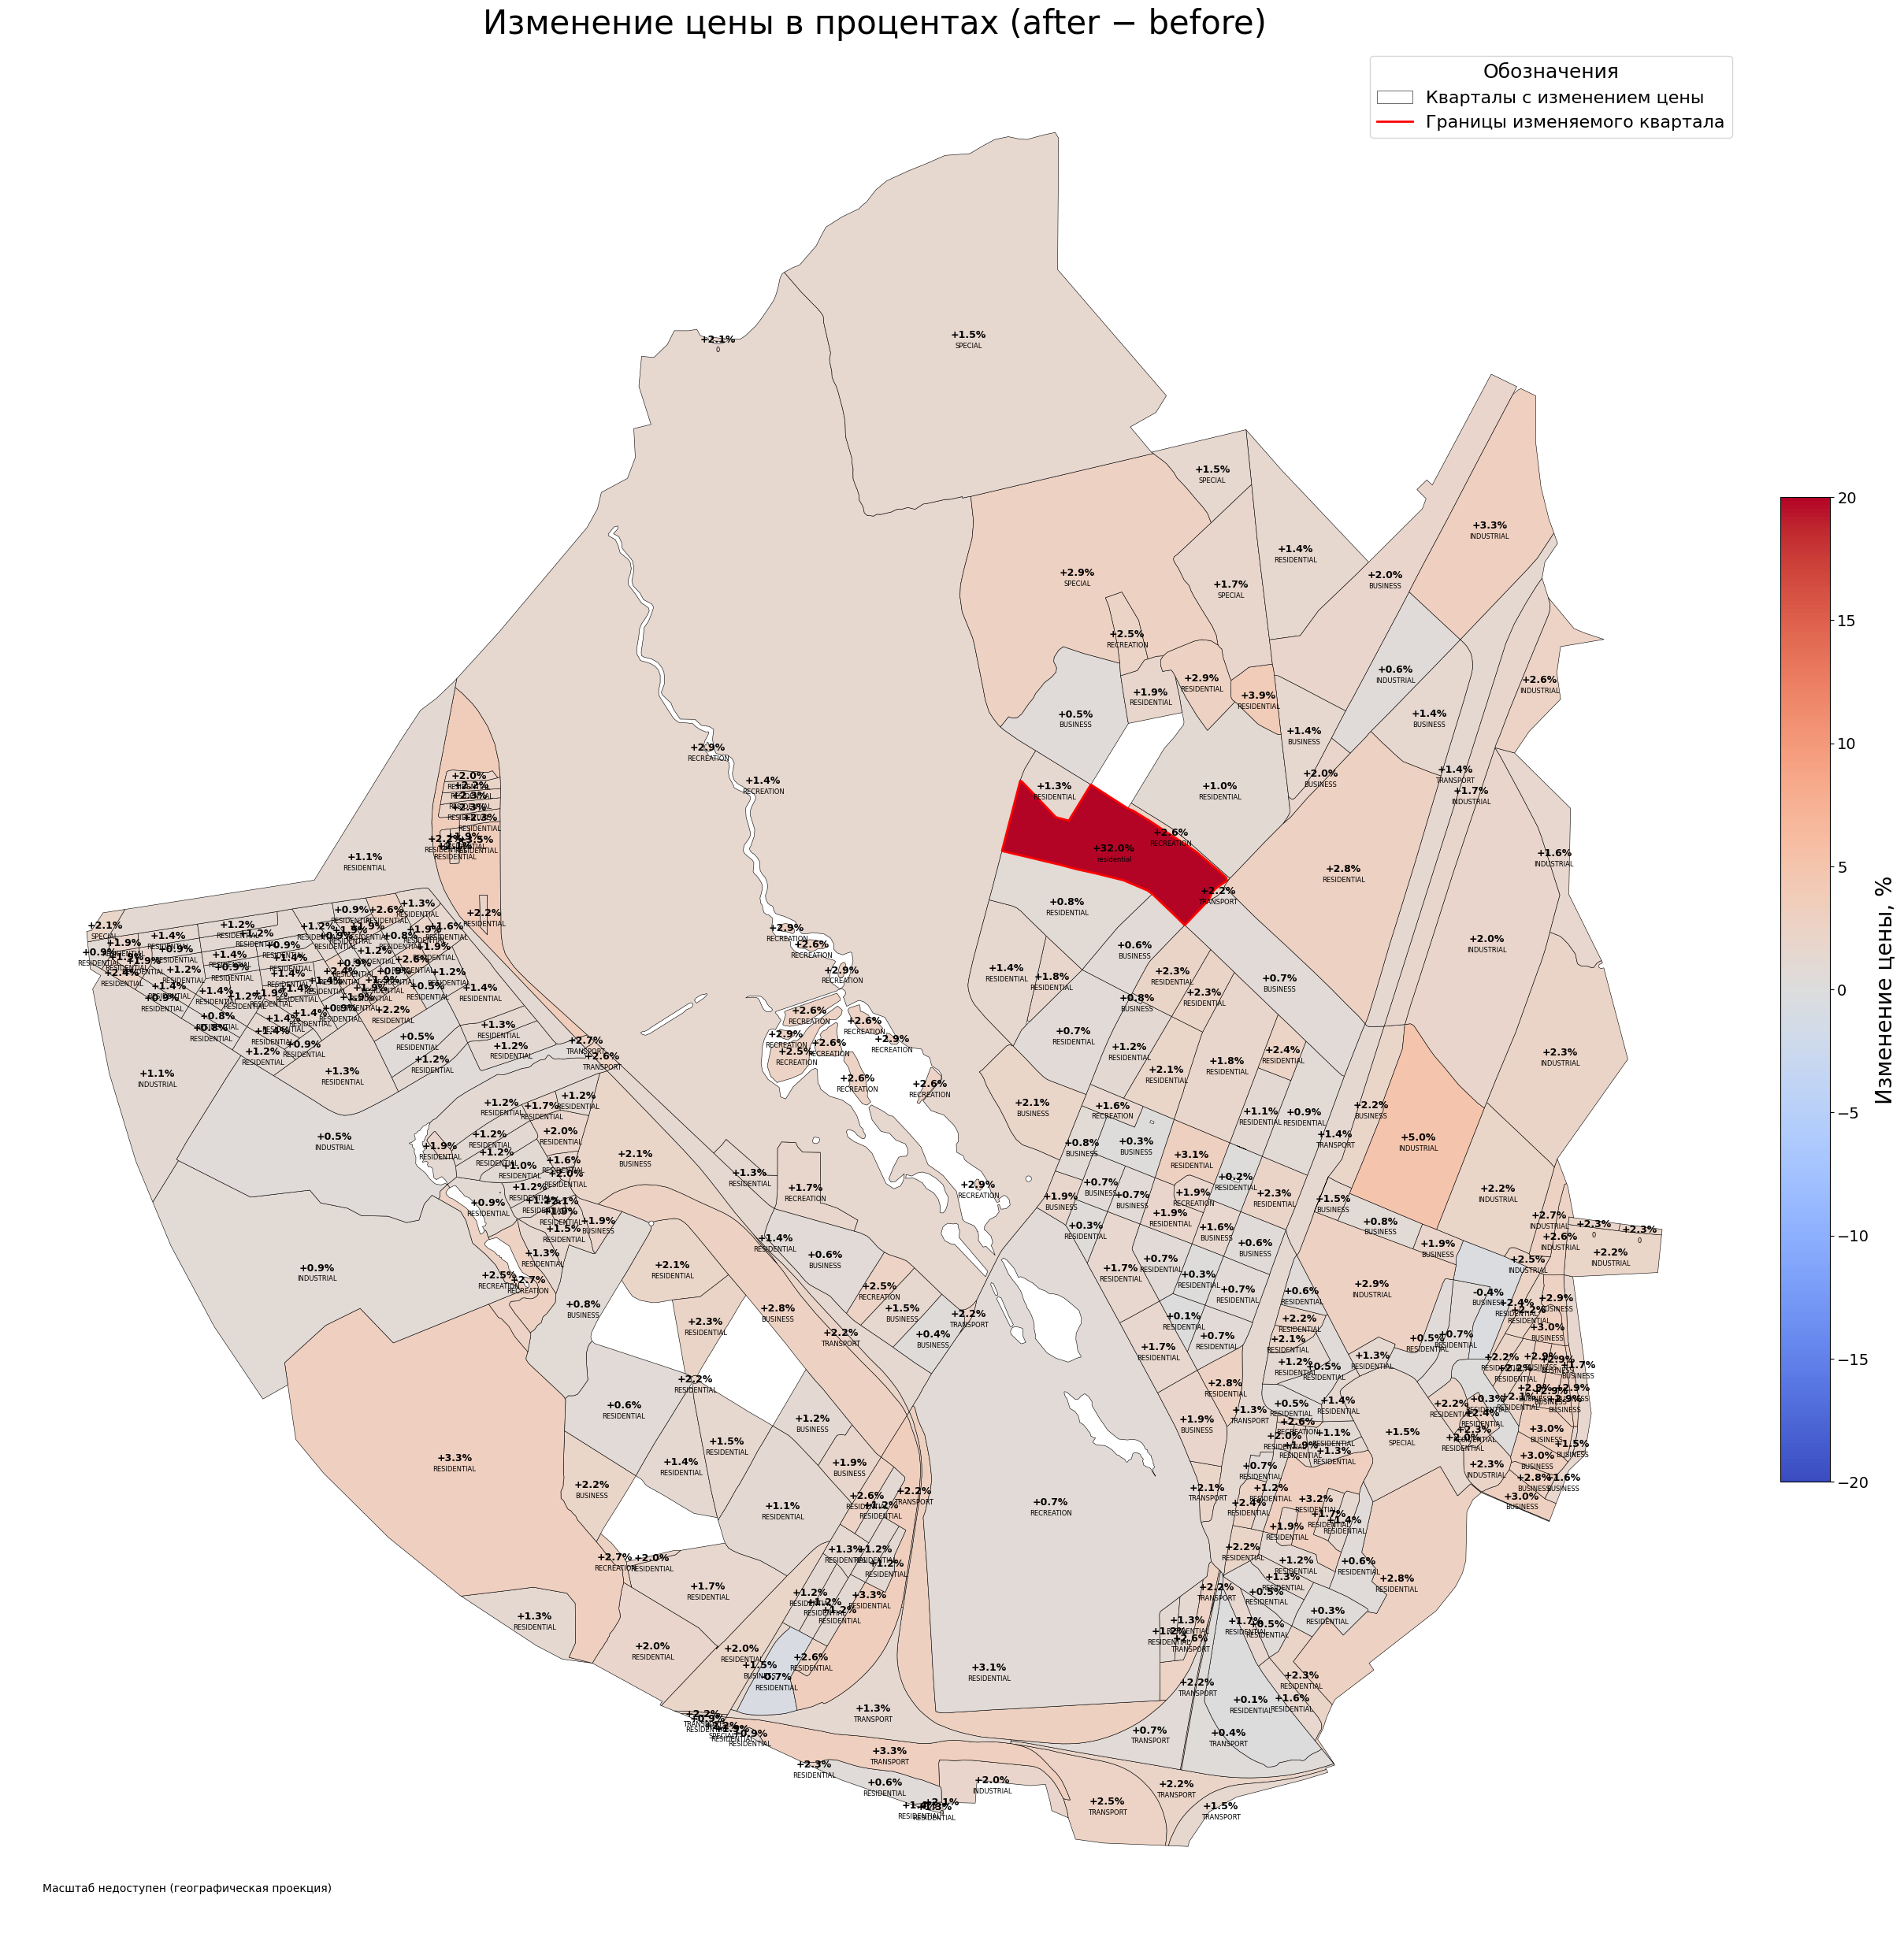

Изменение стоимости земли по всем кварталам:
 • Сумма до:    66 304 589 810 ₽
 • Сумма после: 67 629 643 205 ₽
 • Изм., ₽:     +1 325 053 394 ₽
 • Изм., %:     +2.00%

Изменяемый квартал:
 • До: 741 498 772 ₽ | После: 978 601 523 ₽ | Δ: +237 102 751 ₽ | Δ%: +31.98%

In [ ]:
orchestrator("Визуализируй подорожание земли в решение 3")

In [ ]:
orchestrator("Посчитай инвестиционные метрики для решения 2")

Project totals:
 • Land area:          262,250.98
 • Built area:         241,908.43
 • Land value:         741,498,771.81
 • Demolition cost:    96,396,921.16
 • Construction cost:  10,868,949,516.37
 • Investment need:    11,706,845,209.34
 • Project NPV:        5,920,911,893.72
 • Project IRR:        0.35
 • Project PI:         1.59
 • Project PP (yrs):   5.21

In [ ]:
orchestrator("Что ты запомнил?")

Я запомнил текущий контекст последней оптимизации:

- **target_id:** 86  
- **Найдено решений:** 4  
- **Решения:**  
  1. scenario_0 | RESIDENTIAL | NPV = 5 427 989 082.65  
  2. scenario_1 | RESIDENTIAL | NPV = 5 893 215 666.10  
  3. scenario_2 | RESIDENTIAL | NPV = 5 263 090 570.92  
  4. scenario_3 | RESIDENTIAL | NPV = 6 040 916 464.51  

Также в истории есть запросы о параметрах решений, визуализации стоимости земли и расчёте инвестиционных метрик. Если нужно подробнее о каком‑либо решении или выполнить новую задачу – дайте знать.

### Orchestrator

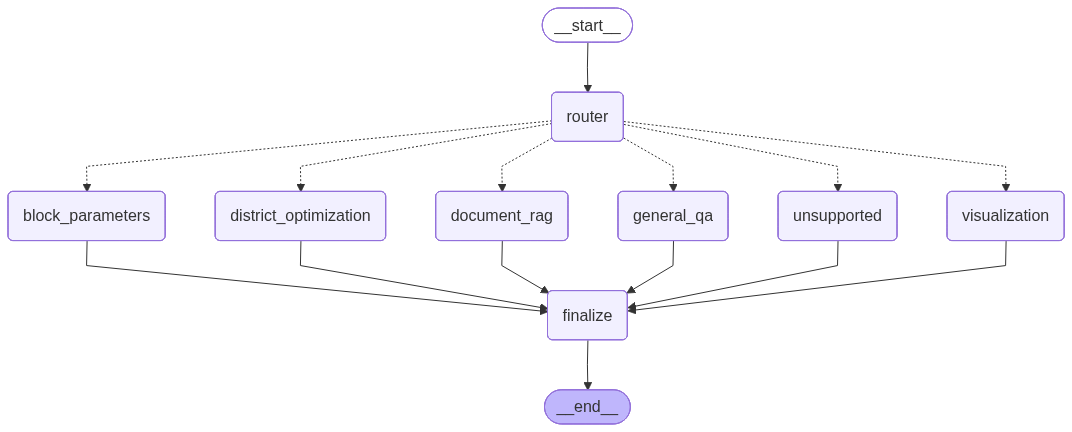

In [42]:
from IPython.display import Image, Markdown, display

from urbanomy.methods.agent_interface import create_urbanomy_orchestrator

orchestrator = create_urbanomy_orchestrator(
    llm=llm,
    baseline_blocks=baseline_blocks,
    district_optimization_config=opt_config,
)


def show_graph(title, compiled_graph, xray=False):
    display(Markdown(f"### {title}"))
    try:
        display(Image(compiled_graph.get_graph(xray=xray).draw_mermaid_png()))
    except Exception:
        mermaid = compiled_graph.get_graph(xray=xray).draw_mermaid()
        display(Markdown(f"```mermaid\n{mermaid}\n```"))


show_graph("Orchestrator", orchestrator.graph, xray=True)
